Auto-rename applied for columns: {'Holding_cost': 'holding', 'Order_cost': 'ordering', 'Shortage_cost': 'shortage', 'Penalty_cost': 'pen_budget'}
   Generation  Time_seconds     Best_cost     Mean_cost      holding  \
0           0      0.000000  6.550918e+10  1.230000e+12          0.0   
1           1      0.073576  3.079982e+10  1.370000e+11  131085041.8   
2           2      0.098662  4.357556e+09  9.373034e+10  124290941.8   
3           3      0.124868  4.356889e+09  3.712890e+10  123084287.8   
4           4      0.150650  1.881672e+08  1.030000e+11  121200927.8   

      ordering   shortage    pen_budget   Method  
0         0.00        0.0  0.000000e+00  HGA-VNS  
1  63189037.63  1964612.0  3.060358e+10  HGA-VNS  
2  63189037.63  2500114.0  4.167576e+09  HGA-VNS  
3  63189037.63  3039300.0  4.167576e+09  HGA-VNS  
4  63189037.63  3777264.0  0.000000e+00  HGA-VNS  
   Generation  Time_seconds     Best_cost     Mean_cost      holding  \
0           0      0.000000  6.550918e+10  

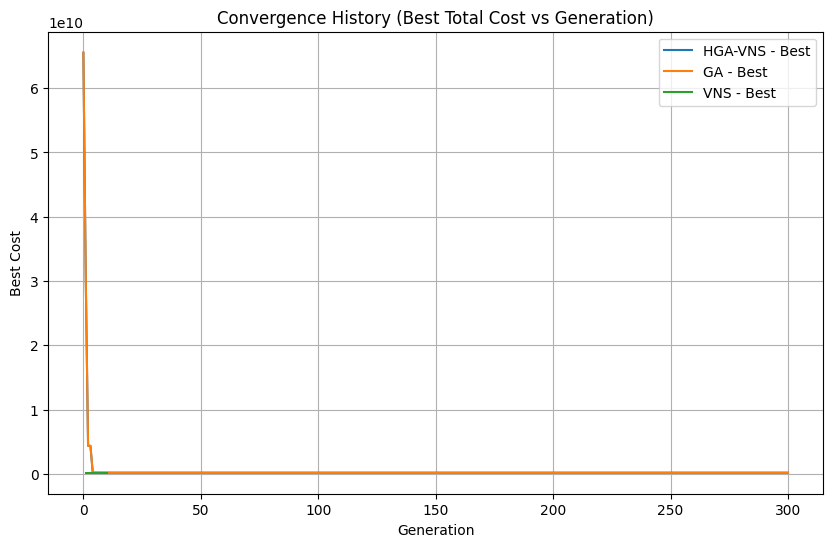

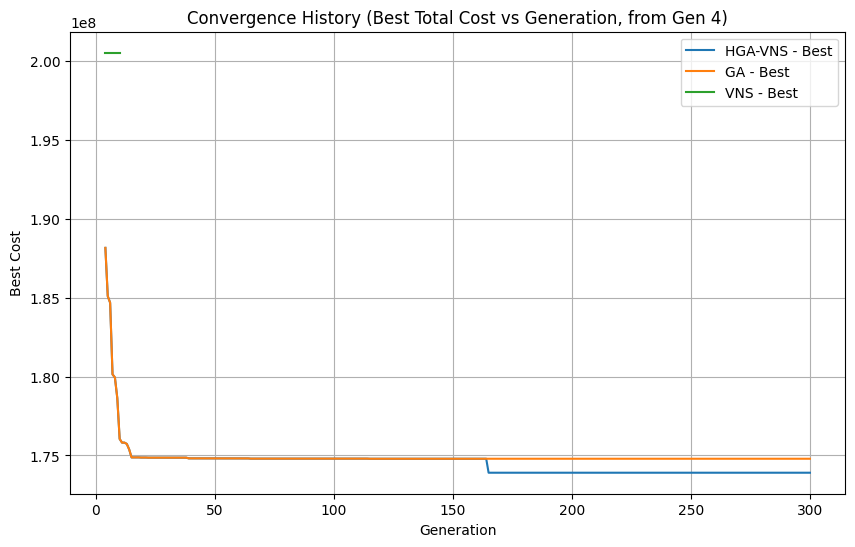

C:\Users\jsantoso\AppData\Local\Temp\ipykernel_65224\92740462.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


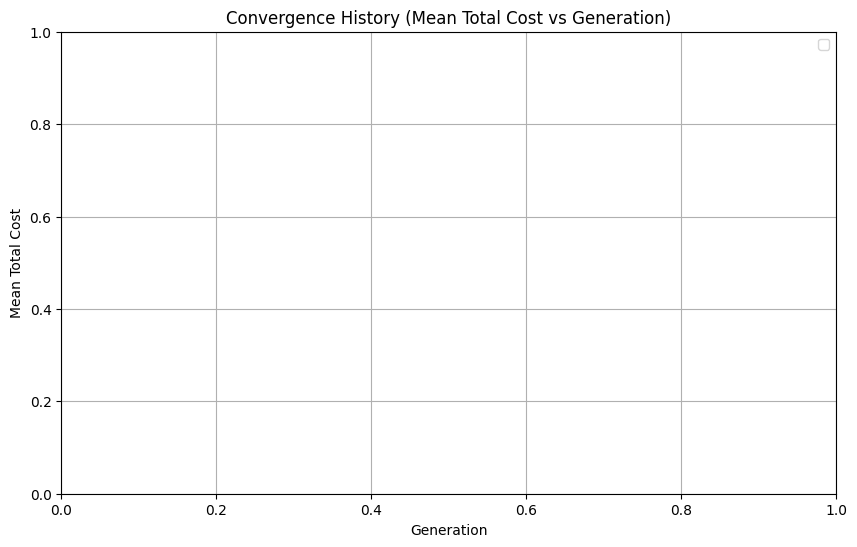

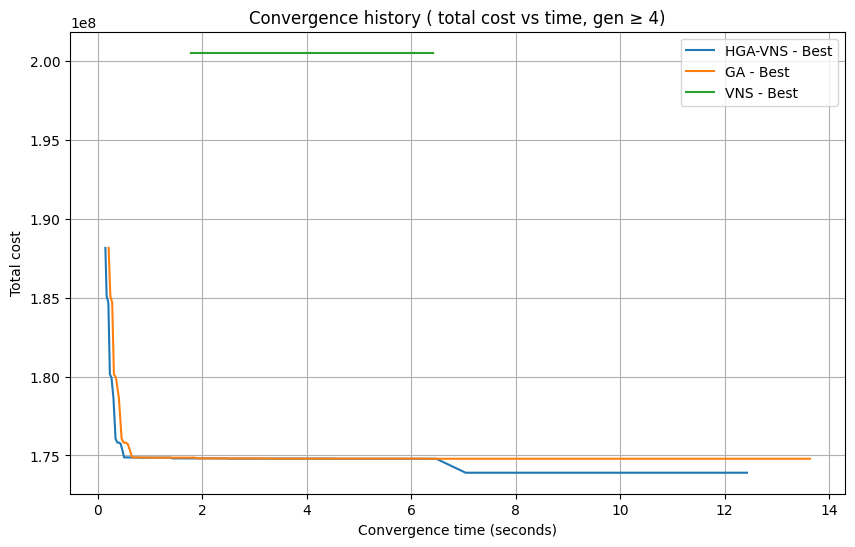

    Method    Best Cost  Generation  Time (s)
0       GA  174794093.5         115  6.336707
1  HGA-VNS  173907697.5         165  7.042780
2      VNS  200542392.2           1  0.356658
Found breakdown columns: ['holding', 'ordering', 'shortage', 'pen_budget']
Found total cost columns for plotting: ['Best_cost']


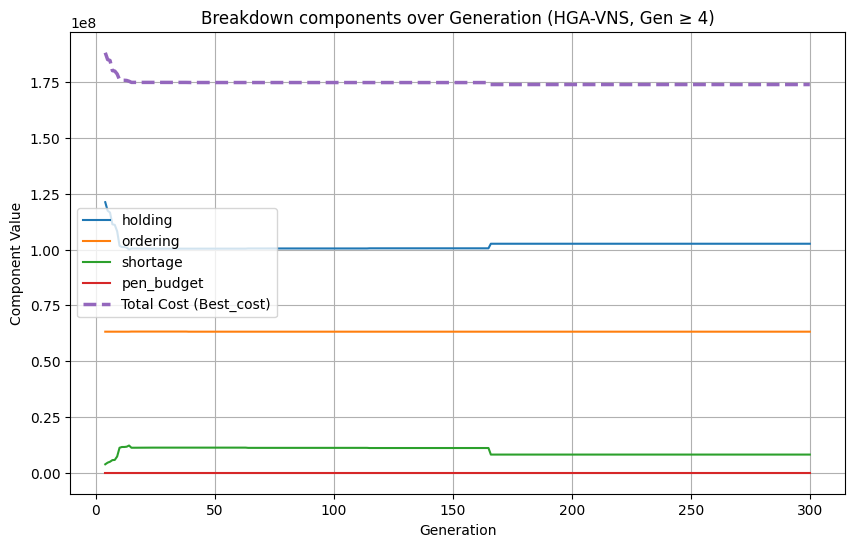

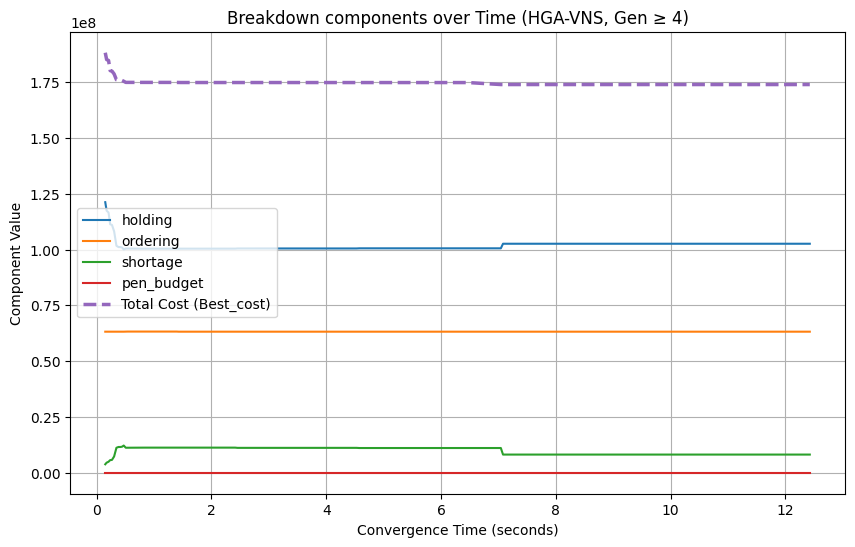

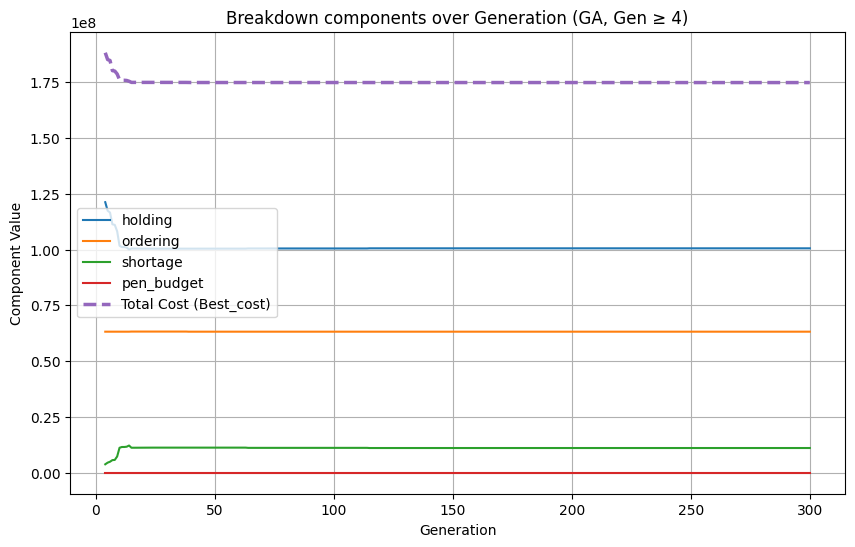

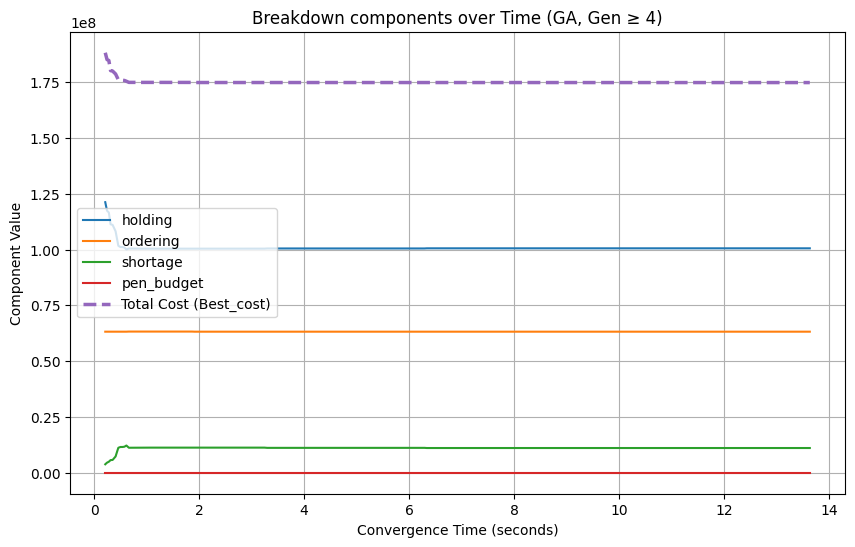

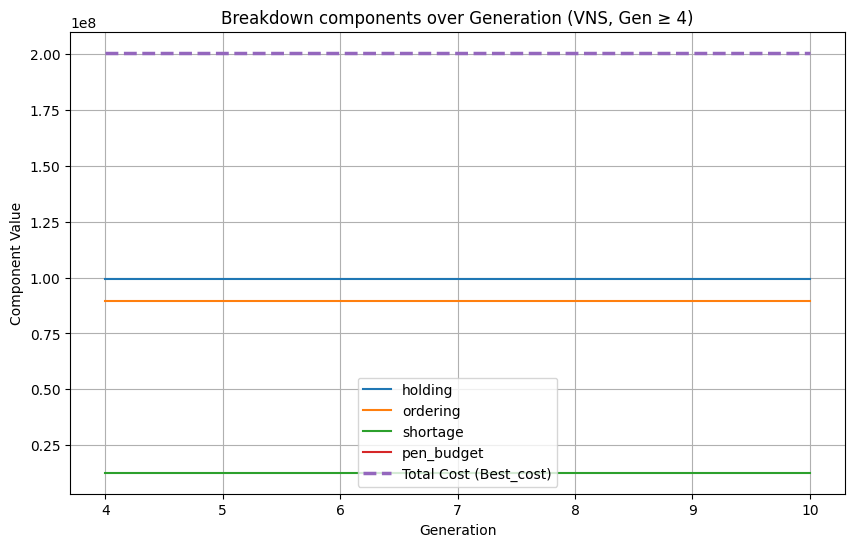

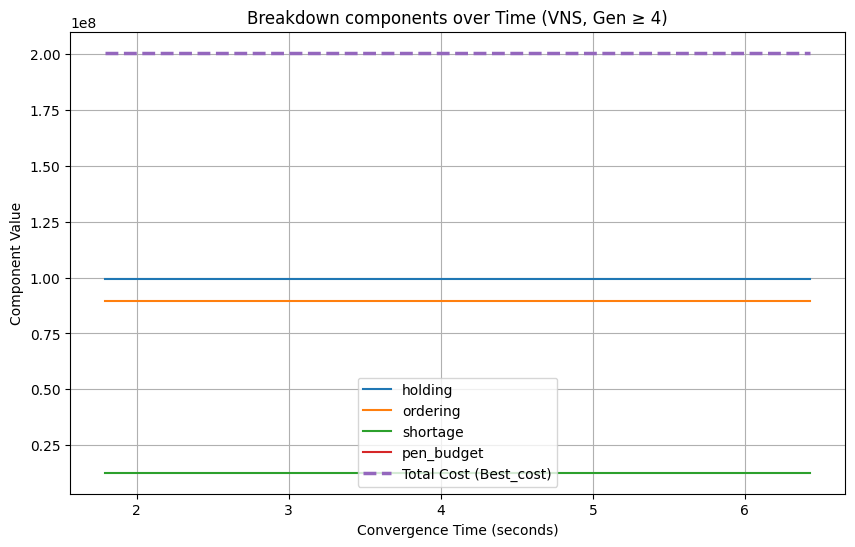

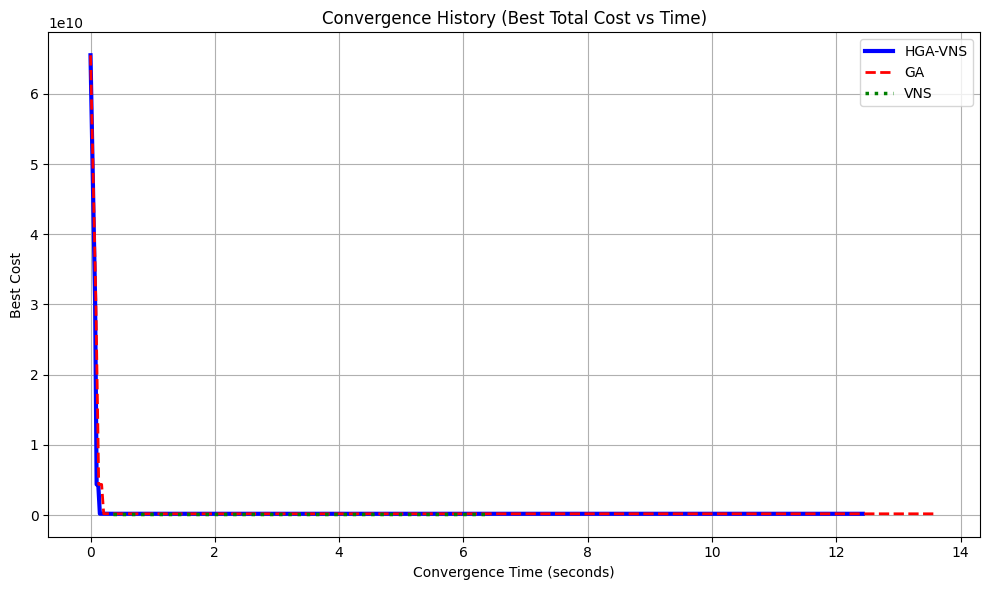

In [21]:
# ===============================
# Convergence History Plotting (with breakdown support)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv("Combined_convergence_history4.csv")

# Clean column names (in case of hidden characters like \\)
df.columns = [col.replace("\\", "").strip() for col in df.columns]

# Normalize alternative breakdown column names (common variants from different exports)
alt_map = {
    'Holding_cost': 'holding', 'HoldingCost': 'holding', 'holding_cost': 'holding',
    'Order_cost': 'ordering', 'OrderCost': 'ordering', 'Order_costs': 'ordering',
    'Shortage_cost': 'shortage', 'ShortageCost': 'shortage', 'Shortage_costs': 'shortage',
    'Penalty_cost': 'pen_budget', 'PenaltyCost': 'pen_budget', 'Penalty_costs': 'pen_budget',
}
rename_map = {k: v for k, v in alt_map.items() if k in df.columns}
if rename_map:
    df = df.rename(columns=rename_map)
    print('Auto-rename applied for columns:', rename_map)

# Display basic info
print(df.head())
print(df.head())
print('\nMethods:', df['Method'].unique())

# ===============================
# Plot 1: Best Cost vs Generation
# ===============================
plt.figure(figsize=(10, 6))

for method in df['Method'].unique():
    subset = df[df['Method'] == method]
    if 'Generation' in subset.columns and 'Best_cost' in subset.columns:
        plt.plot(subset['Generation'], subset['Best_cost'], label=f"{method} - Best")

plt.xlabel("Generation")
plt.ylabel("Best Cost")
plt.title("Convergence History (Best Total Cost vs Generation)")
plt.legend()
plt.grid(True)
plt.show()

# ===============================
# Plot 1b: Best Cost vs Generation (from Generation 4 onwards)
# ===============================
plt.figure(figsize=(10, 6))

for method in df['Method'].unique():
    subset = df[df['Method'] == method]
    subset_filtered = subset[subset['Generation'] >= 4]
    if 'Generation' in subset_filtered.columns and 'Best_cost' in subset_filtered.columns and len(subset_filtered) > 0:
        plt.plot(subset_filtered['Generation'], subset_filtered['Best_cost'], label=f"{method} - Best")

plt.xlabel("Generation")
plt.ylabel("Best Cost")
plt.title("Convergence History (Best Total Cost vs Generation, from Gen 4)")
plt.legend()
plt.grid(True)
plt.show()

# ===============================
# Plot 2: Mean Cost vs Generation
# ===============================
plt.figure(figsize=(10, 6))

for method in df['Method'].unique():
    subset = df[df['Method'] == method]
    # Some methods (like VNS) may not have Mean cost
    if 'Generation' in subset.columns and 'Mean cost' in subset.columns:
        plt.plot(subset['Generation'], subset['Mean cost'], label=f"{method} - Mean")

plt.xlabel("Generation")
plt.ylabel("Mean Total Cost")
plt.title("Convergence History (Mean Total Cost vs Generation)")
plt.legend()
plt.grid(True)
plt.show()

# ===============================
# Plot 3: Best Cost vs Time (from Generation 4 onwards)
# ===============================
plt.figure(figsize=(10, 6))

for method in df['Method'].unique():
    subset = df[df['Method'] == method]
    subset_filtered = subset[subset['Generation'] >= 4]
    if 'Time_seconds' in subset_filtered.columns and 'Best_cost' in subset_filtered.columns and len(subset_filtered) > 0:
        plt.plot(subset_filtered['Time_seconds'], subset_filtered['Best_cost'], label=f"{method} - Best")

plt.xlabel("Convergence time (seconds)")
plt.ylabel("Total cost")
plt.title("Convergence history ( total cost vs time, gen ≥ 4)")
plt.legend()
plt.grid(True)
plt.show()

# ===============================
# Best result per method
# ===============================
best_results = []

for method, g in df.groupby('Method'):
    if 'Best_cost' in g.columns:
        idx = g['Best_cost'].idxmin()
        row = g.loc[idx]
        best_results.append({
            'Method': method,
            'Best Cost': row.get('Best_cost', np.nan),
            'Generation': row.get('Generation', np.nan),
            'Time (s)': row.get('Time_seconds', np.nan)
        })

best_df = pd.DataFrame(best_results)
print(best_df)

# ===============================
# Breakdown plotting (if breakdown columns present)
# ===============================
breakdown_candidates = [
    'holding', 'ordering', 'shortage', 'order_miss_penalty', 'pen_cap',
    'pen_q_leq_d', 'pen_ss', 'pen_budget', 'pen_fill', 'fill_rate'
]
breakdown_cols = [c for c in breakdown_candidates if c in df.columns]
total_cost_cols = [c for c in ['Total_cost', 'Total Cost', 'Best_cost'] if c in df.columns]

if len(breakdown_cols) == 0:
    print('No breakdown columns found in CSV. Available columns:', df.columns.tolist())
else:
    print('Found breakdown columns:', breakdown_cols)
    print('Found total cost columns for plotting:', total_cost_cols)
    # Plot breakdown components per method vs Generation and vs Time (from Generation 4 onwards)
    for method in df['Method'].unique():
        subset = df[df['Method'] == method]
        subset_filtered = subset[subset['Generation'] >= 4]
        # Plot vs Generation if available
        if 'Generation' in subset_filtered.columns and len(subset_filtered) > 0:
            plt.figure(figsize=(10, 6))
            for col in breakdown_cols:
                if col in subset_filtered.columns:
                    plt.plot(subset_filtered['Generation'], subset_filtered[col], label=col)
            for col in total_cost_cols:
                if col in subset_filtered.columns:
                    plt.plot(
                        subset_filtered['Generation'],
                        subset_filtered[col],
                        label=f'Total Cost ({col})',
                        linestyle='--',
                        linewidth=2.5
                    )
            plt.xlabel('Generation')
            plt.ylabel('Component Value')
            plt.title(f'Breakdown components over Generation ({method}, Gen ≥ 4)')
            plt.legend()
            plt.grid(True)
            plt.show()
        # Plot vs Time_seconds if available
        if 'Time_seconds' in subset_filtered.columns and len(subset_filtered) > 0:
            plt.figure(figsize=(10, 6))
            for col in breakdown_cols:
                if col in subset_filtered.columns:
                    plt.plot(subset_filtered['Time_seconds'], subset_filtered[col], label=col)
            for col in total_cost_cols:
                if col in subset_filtered.columns:
                    plt.plot(
                        subset_filtered['Time_seconds'],
                        subset_filtered[col],
                        label=f'Total Cost ({col})',
                        linestyle='--',
                        linewidth=2.5
                    )
            plt.xlabel('Convergence Time (seconds)')
            plt.ylabel('Component Value')
            plt.title(f'Breakdown components over Time ({method}, Gen ≥ 4)')
            plt.legend()
            plt.grid(True)
            plt.show()

# ===============================
# Plot: Best Cost vs Time (styled)
# ===============================
plt.figure(figsize=(10, 6))

# Define styles for each method
line_styles = {
    'HGA-VNS': {'linestyle': '-',  'linewidth': 3},   # solid, thick
    'GA':      {'linestyle': '--', 'linewidth': 2},   # dashed
    'VNS':     {'linestyle': ':',  'linewidth': 2.5}  # dotted
}

# Optional: define colors for consistency
colors = {
    'HGA-VNS': 'blue',
    'GA': 'red',
    'VNS': 'green'
}

for method in df['Method'].unique():
    subset = df[df['Method'] == method]
    if 'Time_seconds' in subset.columns and 'Best_cost' in subset.columns:
        plt.plot(
            subset['Time_seconds'],
            subset['Best_cost'],   # adjust if your column name uses space
            label=f"{method}",
            linestyle=line_styles.get(method, {}).get('linestyle', '-'),
            linewidth=line_styles.get(method, {}).get('linewidth', 2),
            color=colors.get(method, None)
        )

plt.xlabel("Convergence Time (seconds)")
plt.ylabel("Best Cost")
plt.title("Convergence History (Best Total Cost vs Time)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
